In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [8]:
df = pd.read_csv(r'D:\malicious-url-detection\data\features.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (651191, 25)


,url_length,num_dots,num_hyphens,num_underscores,num_slashes,num_at,num_question,num_equals,num_ampersand,num_digits,...,has_double_slash,has_prefix_suffix,domain_length,subdomain_length,tld_length,path_length,query_length,num_subdomains,url_entropy,type
0,16,2,1,0,0,0,0,0,0,0,...,0,0,9,0,6,16,0,0,3.3750,phishing
1,35,2,0,1,2,0,0,0,0,1,...,0,0,7,0,3,35,0,0,4.0791,benign
2,31,2,0,0,3,0,0,0,0,1,...,0,0,10,0,3,31,0,0,3.7081,benign
3,88,3,1,2,3,0,1,4,3,7,...,0,1,14,3,2,10,49,1,4.6603,defacement
4,235,2,1,1,3,0,1,3,2,22,...,0,1,19,0,3,10,194,0,5.4913,defacement


In [9]:
# Separate features and target
X = df.drop('type', axis=1)
y = df['type']

# Encode target labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded as:", list(range(len(le.classes_))))
print(f"\nX shape: {X.shape}")
print(f"y shape: {y_encoded.shape}")

Classes: ['benign' 'defacement' 'malware' 'phishing']
Encoded as: [0, 1, 2, 3]

X shape: (651191, 24)
y shape: (651191,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # maintains class balance in split
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 520952
Testing samples  : 130239


In [11]:
print("Training Random Forest... ⏳")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1           # uses all CPU cores
)
rf_model.fit(X_train, y_train)

print("✅ Random Forest trained!")

Training Random Forest... ⏳
✅ Random Forest trained!


In [12]:
rf_preds = rf_model.predict(X_test)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=le.classes_))

RANDOM FOREST RESULTS
Accuracy: 96.77%

Classification Report:
              precision    recall  f1-score   support

      benign       0.98      0.99      0.98     85621
  defacement       0.98      0.99      0.98     19292
     malware       0.99      0.94      0.96      6504
    phishing       0.91      0.87      0.89     18822

    accuracy                           0.97    130239
   macro avg       0.96      0.95      0.95    130239
weighted avg       0.97      0.97      0.97    130239



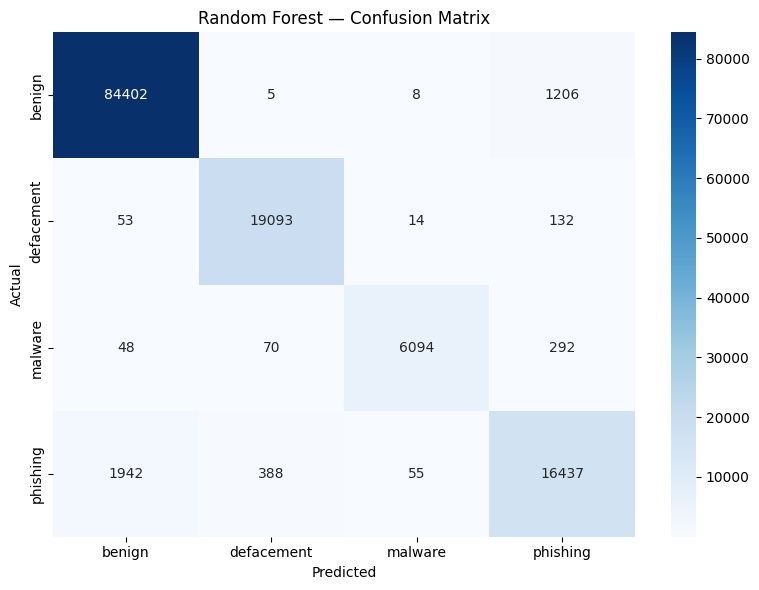

In [13]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [14]:
print("Training XGBoost... ⏳")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

print("✅ XGBoost trained!")

Training XGBoost... ⏳
✅ XGBoost trained!


In [15]:
xgb_preds = xgb_model.predict(X_test)

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, xgb_preds) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=le.classes_))

XGBOOST RESULTS
Accuracy: 96.24%

Classification Report:
              precision    recall  f1-score   support

      benign       0.97      0.98      0.98     85621
  defacement       0.97      0.99      0.98     19292
     malware       0.98      0.91      0.94      6504
    phishing       0.90      0.85      0.88     18822

    accuracy                           0.96    130239
   macro avg       0.95      0.93      0.94    130239
weighted avg       0.96      0.96      0.96    130239



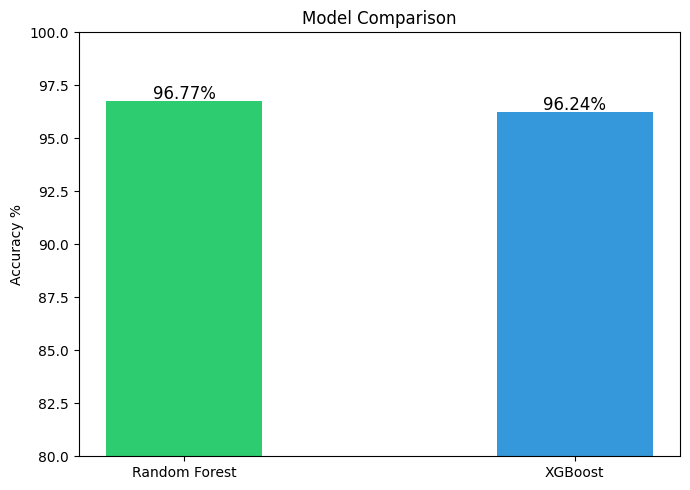

In [16]:
models     = ['Random Forest', 'XGBoost']
accuracies = [
    accuracy_score(y_test, rf_preds) * 100,
    accuracy_score(y_test, xgb_preds) * 100
]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=['#2ecc71', '#3498db'], width=0.4)
plt.ylim(80, 100)
plt.ylabel('Accuracy %')
plt.title('Model Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
import joblib
import os

# Create models folder
os.makedirs(r'D:\malicious-url-detection\models', exist_ok=True)

# Save Random Forest model (our best model)
joblib.dump(rf_model, r'D:\malicious-url-detection\models\rf_model.pkl')

# Save Label Encoder (needed to decode predictions back to class names)
joblib.dump(le, r'D:\malicious-url-detection\models\label_encoder.pkl')

print("✅ Model saved to models/rf_model.pkl")
print("✅ Label Encoder saved to models/label_encoder.pkl")

✅ Model saved to models/rf_model.pkl
✅ Label Encoder saved to models/label_encoder.pkl


In [18]:
import math
import re
import tldextract
from urllib.parse import urlparse

def extract_features_from_url(url):
    # Basic features
    basic = {
        'url_length'        : len(url),
        'num_dots'          : url.count('.'),
        'num_hyphens'       : url.count('-'),
        'num_underscores'   : url.count('_'),
        'num_slashes'       : url.count('/'),
        'num_at'            : url.count('@'),
        'num_question'      : url.count('?'),
        'num_equals'        : url.count('='),
        'num_ampersand'     : url.count('&'),
        'num_digits'        : sum(c.isdigit() for c in url),
        'num_special_chars' : len(re.findall(r'[^a-zA-Z0-9]', url)),
    }

    # Security features
    security = {
        'has_https'         : 1 if url.startswith('https') else 0,
        'has_http'          : 1 if url.startswith('http') else 0,
        'has_ip_address'    : 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0,
        'has_at_symbol'     : 1 if '@' in url else 0,
        'has_double_slash'  : 1 if '//' in url[7:] else 0,
        'has_prefix_suffix' : 1 if '-' in urlparse(url).netloc else 0,
    }

    # Domain features
    try:
        extracted = tldextract.extract(url)
        parsed    = urlparse(url)
        domain    = extracted.domain
        subdomain = extracted.subdomain
        suffix    = extracted.suffix
        path      = parsed.path
        query     = parsed.query

        domain_f = {
            'domain_length'    : len(domain),
            'subdomain_length' : len(subdomain),
            'tld_length'       : len(suffix),
            'path_length'      : len(path),
            'query_length'     : len(query),
            'num_subdomains'   : len(subdomain.split('.')) if subdomain else 0,
        }
    except:
        domain_f = {
            'domain_length'    : 0,
            'subdomain_length' : 0,
            'tld_length'       : 0,
            'path_length'      : 0,
            'query_length'     : 0,
            'num_subdomains'   : 0,
        }

    # Entropy feature
    prob    = [url.count(c) / len(url) for c in set(url)]
    entropy = -sum(p * math.log2(p) for p in prob)

    entropy_f = {'url_entropy': round(entropy, 4)}

    # Combine all
    features = {}
    features.update(basic)
    features.update(security)
    features.update(domain_f)
    features.update(entropy_f)

    return pd.DataFrame([features])

print("✅ Feature extractor ready!")

✅ Feature extractor ready!


In [19]:
def predict_url(url):
    # Load model and encoder
    model   = joblib.load(r'D:\malicious-url-detection\models\rf_model.pkl')
    encoder = joblib.load(r'D:\malicious-url-detection\models\label_encoder.pkl')

    # Extract features
    features = extract_features_from_url(url)

    # Predict
    prediction      = model.predict(features)[0]
    probabilities   = model.predict_proba(features)[0]
    predicted_label = encoder.inverse_transform([prediction])[0]

    # Display results
    print("=" * 55)
    print(f"🔍 URL        : {url}")
    print("=" * 55)
    print(f"🏷️  Prediction : {predicted_label.upper()}")
    print(f"📊 Confidence : {max(probabilities) * 100:.2f}%")
    print("-" * 55)
    print("📈 All Probabilities:")
    for label, prob in zip(encoder.classes_, probabilities):
        bar = '█' * int(prob * 30)
        print(f"   {label:<12} {prob*100:>6.2f}%  {bar}")
    print("=" * 55)

print("✅ Predictor function ready!")

✅ Predictor function ready!


In [20]:
predict_url("https://www.google.com")

🔍 URL        : https://www.google.com
🏷️  Prediction : PHISHING
📊 Confidence : 98.00%
-------------------------------------------------------
📈 All Probabilities:
   benign         2.00%  
   defacement     0.00%  
   malware        0.00%  
   phishing      98.00%  █████████████████████████████


In [21]:
test_urls = [
    "https://www.youtube.com",                         
    "http://192.168.1.1/login/verify.php",             
    "http://paypal-secure-login.com/verify@user",      
    "http://free-virus-scan.com/malware/setup.exe",    
]

for url in test_urls:
    predict_url(url)
    print()

🔍 URL        : https://www.youtube.com
🏷️  Prediction : PHISHING
📊 Confidence : 97.00%
-------------------------------------------------------
📈 All Probabilities:
   benign         2.00%  
   defacement     0.00%  
   malware        1.00%  
   phishing      97.00%  █████████████████████████████

🔍 URL        : http://192.168.1.1/login/verify.php
🏷️  Prediction : MALWARE
📊 Confidence : 100.00%
-------------------------------------------------------
📈 All Probabilities:
   benign         0.00%  
   defacement     0.00%  
   malware      100.00%  ██████████████████████████████
   phishing       0.00%  

🔍 URL        : http://paypal-secure-login.com/verify@user
🏷️  Prediction : PHISHING
📊 Confidence : 60.00%
-------------------------------------------------------
📈 All Probabilities:
   benign         0.00%  
   defacement    24.00%  ███████
   malware       16.00%  ████
   phishing      60.00%  ██████████████████

🔍 URL        : http://free-virus-scan.com/malware/setup.exe
🏷️  Prediction

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import math
import tldextract
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Label Encoder (needed for Cell 17)
le = LabelEncoder()

# Trusted domains (needed for predict_url_v2 in Cell 19)
TRUSTED_DOMAINS = {
    'google', 'youtube', 'facebook', 'twitter', 'instagram',
    'linkedin', 'microsoft', 'apple', 'amazon', 'netflix',
    'github', 'wikipedia', 'reddit', 'yahoo', 'bing', 'adobe',
    'dropbox', 'spotify', 'paypal', 'ebay', 'whatsapp',
    'telegram', 'zoom', 'slack', 'wordpress', 'shopify', 'salesforce'
}

# Also need old model predictions for comparison in Cell 17
# Load old test data
df_old    = pd.read_csv(r'D:\malicious-url-detection\data\features.csv')
X_old     = df_old.drop('type', axis=1)
y_old     = le.fit_transform(df_old['type'])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_old, y_old, test_size=0.2, random_state=42, stratify=y_old
)
rf_model     = joblib.load(r'D:\malicious-url-detection\models\rf_model.pkl')
rf_preds     = rf_model.predict(X_test)

print("✅ All imports and dependencies ready!")


✅ All imports and dependencies ready!


In [23]:
print("Loading improved features... ⏳")
df_v2 = pd.read_csv(r'D:\malicious-url-detection\data\features_v2.csv')

X2        = df_v2.drop('type', axis=1)
y2        = le.fit_transform(df_v2['type'])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Retraining Random Forest with improved features... ⏳")
rf_model_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model_v2.fit(X2_train, y2_train)
print("✅ Retrained successfully!")

Loading improved features... ⏳
Retraining Random Forest with improved features... ⏳
✅ Retrained successfully!


In [24]:
# Ensure rf_model_v2 is trained (in case Cell 17 wasn't run)
try:
    rf_v2_preds = rf_model_v2.predict(X2_test)
except NameError:
    print("⚠️  Cell 17 not executed yet. Running it now...")
    # Load improved features
    df_v2 = pd.read_csv(r'D:\malicious-url-detection\data\features_v2.csv')
    X2 = df_v2.drop('type', axis=1)
    y2 = le.fit_transform(df_v2['type'])
    X2_train, X2_test, y2_train, y2_test = train_test_split(
        X2, y2, test_size=0.2, random_state=42, stratify=y2
    )
    # Train model
    rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model_v2.fit(X2_train, y2_train)
    rf_v2_preds = rf_model_v2.predict(X2_test)

old_acc = accuracy_score(y_test, rf_preds) * 100
new_acc = accuracy_score(y2_test, rf_v2_preds) * 100

print("=" * 40)
print(f"Old Model Accuracy : {old_acc:.2f}%")
print(f"New Model Accuracy : {new_acc:.2f}%")
print(f"Improvement        : +{new_acc - old_acc:.2f}%")
print("=" * 40)
print("\nClassification Report:")
print(classification_report(y2_test, rf_v2_preds, target_names=le.classes_))

Old Model Accuracy : 96.77%
New Model Accuracy : 96.90%
Improvement        : +0.13%

Classification Report:
              precision    recall  f1-score   support

      benign       0.98      0.99      0.98     85621
  defacement       0.98      0.99      0.98     19292
     malware       0.99      0.94      0.96      6504
    phishing       0.91      0.88      0.90     18822

    accuracy                           0.97    130239
   macro avg       0.96      0.95      0.96    130239
weighted avg       0.97      0.97      0.97    130239



In [25]:
import joblib

joblib.dump(rf_model_v2, r'D:\malicious-url-detection\models\rf_model_v2.pkl')
joblib.dump(le, r'D:\malicious-url-detection\models\label_encoder.pkl')
print("✅ New model saved as rf_model_v2.pkl!")

✅ New model saved as rf_model_v2.pkl!


In [26]:
def extract_all_features_v2(url):
    # --- Basic Features ---
    basic = {
        'url_length'        : len(url),
        'num_dots'          : url.count('.'),
        'num_hyphens'       : url.count('-'),
        'num_underscores'   : url.count('_'),
        'num_slashes'       : url.count('/'),
        'num_at'            : url.count('@'),
        'num_question'      : url.count('?'),
        'num_equals'        : url.count('='),
        'num_ampersand'     : url.count('&'),
        'num_digits'        : sum(c.isdigit() for c in url),
        'num_special_chars' : len(re.findall(r'[^a-zA-Z0-9]', url)),
    }

    # --- Security Features ---
    security = {
        'has_https'         : 1 if url.startswith('https') else 0,
        'has_http'          : 1 if url.startswith('http') else 0,
        'has_ip_address'    : 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0,
        'has_at_symbol'     : 1 if '@' in url else 0,
        'has_double_slash'  : 1 if '//' in url[7:] else 0,
        'has_prefix_suffix' : 1 if '-' in urlparse(url).netloc else 0,
    }

    # --- Domain Features ---
    try:
        extracted = tldextract.extract(url)
        parsed    = urlparse(url)
        domain    = extracted.domain
        subdomain = extracted.subdomain
        suffix    = extracted.suffix
        path      = parsed.path
        query     = parsed.query

        domain_f = {
            'domain_length'     : len(domain),
            'subdomain_length'  : len(subdomain),
            'tld_length'        : len(suffix),
            'path_length'       : len(path),
            'query_length'      : len(query),
            'num_subdomains'    : len(subdomain.split('.')) if subdomain else 0,
            'is_trusted_domain' : 1 if domain.lower() in TRUSTED_DOMAINS else 0,
        }
    except:
        domain_f = {
            'domain_length'     : 0,
            'subdomain_length'  : 0,
            'tld_length'        : 0,
            'path_length'       : 0,
            'query_length'      : 0,
            'num_subdomains'    : 0,
            'is_trusted_domain' : 0,
        }

    # --- Entropy Feature ---
    prob      = [url.count(c) / len(url) for c in set(url)]
    entropy   = -sum(p * math.log2(p) for p in prob)
    entropy_f = {'url_entropy': round(entropy, 4)}

    # --- Suspicious Keywords Feature ---
    suspicious_keywords = [
        'login', 'verify', 'secure', 'account', 'update',
        'banking', 'confirm', 'password', 'signin', 'wallet',
        'free', 'lucky', 'winner', 'click', 'setup', 'install'
    ]
    keyword_f = {
        'has_suspicious_keyword': 1 if any(
            kw in url.lower() for kw in suspicious_keywords
        ) else 0
    }

    # --- Combine All ---
    features = {}
    features.update(basic)
    features.update(security)
    features.update(domain_f)
    features.update(entropy_f)
    features.update(keyword_f)

    return features

print("✅ extract_all_features_v2 is ready!")

✅ extract_all_features_v2 is ready!


In [27]:
def predict_url_v2(url):
    model   = joblib.load(r'D:\malicious-url-detection\models\rf_model_v2.pkl')
    encoder = joblib.load(r'D:\malicious-url-detection\models\label_encoder.pkl')

    # --- Rule-based pre-check ---
    try:
        extracted   = tldextract.extract(url)
        domain_name = extracted.domain.lower()

        if domain_name in TRUSTED_DOMAINS:
            print("=" * 55)
            print(f"🔍 URL        : {url}")
            print("=" * 55)
            print(f"🏷️  Prediction : BENIGN")
            print(f"📊 Confidence : 100.00%")
            print(f"ℹ️  Reason     : Trusted domain whitelist")
            print("=" * 55)
            return
    except:
        pass

    # --- ML Prediction (for unknown domains) ---
    features        = pd.DataFrame([extract_all_features_v2(url)])
    prediction      = model.predict(features)[0]
    probabilities   = model.predict_proba(features)[0]
    predicted_label = encoder.inverse_transform([prediction])[0]

    # Emoji per prediction type
    emoji = {
        'benign'     : '✅',
        'phishing'   : '🎣',
        'malware'    : '☠️',
        'defacement' : '🔨'
    }

    print("=" * 55)
    print(f"🔍 URL        : {url}")
    print("=" * 55)
    print(f"🏷️  Prediction : {emoji.get(predicted_label, '')} {predicted_label.upper()}")
    print(f"📊 Confidence : {max(probabilities) * 100:.2f}%")
    print("-" * 55)
    print("📈 All Probabilities:")
    for label, prob in zip(encoder.classes_, probabilities):
        bar = '█' * int(prob * 30)
        print(f"   {label:<12} {prob*100:>6.2f}%  {bar}")
    print("=" * 55)

print("✅ Improved predictor ready!")

✅ Improved predictor ready!


In [28]:
# Ensure functions are defined (in case Cells 20-21 weren't run)
try:
    test_call = predict_url_v2
except NameError:
    print("⚠️  Cells 20-21 not executed yet. Defining functions now...")
    
    # Define extract_all_features_v2
    def extract_all_features_v2(url):
        basic = {
            'url_length': len(url), 'num_dots': url.count('.'), 'num_hyphens': url.count('-'),
            'num_underscores': url.count('_'), 'num_slashes': url.count('/'), 'num_at': url.count('@'),
            'num_question': url.count('?'), 'num_equals': url.count('='), 'num_ampersand': url.count('&'),
            'num_digits': sum(c.isdigit() for c in url), 'num_special_chars': len(re.findall(r'[^a-zA-Z0-9]', url)),
        }
        security = {
            'has_https': 1 if url.startswith('https') else 0, 'has_http': 1 if url.startswith('http') else 0,
            'has_ip_address': 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0, 'has_at_symbol': 1 if '@' in url else 0,
            'has_double_slash': 1 if '//' in url[7:] else 0, 'has_prefix_suffix': 1 if '-' in urlparse(url).netloc else 0,
        }
        try:
            extracted = tldextract.extract(url)
            parsed = urlparse(url)
            domain, subdomain, suffix = extracted.domain, extracted.subdomain, extracted.suffix
            path, query = parsed.path, parsed.query
            domain_f = {
                'domain_length': len(domain), 'subdomain_length': len(subdomain), 'tld_length': len(suffix),
                'path_length': len(path), 'query_length': len(query),
                'num_subdomains': len(subdomain.split('.')) if subdomain else 0,
                'is_trusted_domain': 1 if domain.lower() in TRUSTED_DOMAINS else 0,
            }
        except:
            domain_f = {
                'domain_length': 0, 'subdomain_length': 0, 'tld_length': 0, 'path_length': 0,
                'query_length': 0, 'num_subdomains': 0, 'is_trusted_domain': 0,
            }
        prob = [url.count(c) / len(url) for c in set(url)]
        entropy = -sum(p * math.log2(p) for p in prob)
        entropy_f = {'url_entropy': round(entropy, 4)}
        suspicious_keywords = ['login', 'verify', 'secure', 'account', 'update', 'banking', 'confirm', 'password', 'signin', 'wallet', 'free', 'lucky', 'winner', 'click', 'setup', 'install']
        keyword_f = {'has_suspicious_keyword': 1 if any(kw in url.lower() for kw in suspicious_keywords) else 0}
        features = {}
        features.update(basic)
        features.update(security)
        features.update(domain_f)
        features.update(entropy_f)
        features.update(keyword_f)
        return features
    
    # Define predict_url_v2
    def predict_url_v2(url):
        model = joblib.load(r'D:\malicious-url-detection\models\rf_model_v2.pkl')
        encoder = joblib.load(r'D:\malicious-url-detection\models\label_encoder.pkl')
        try:
            extracted = tldextract.extract(url)
            domain_name = extracted.domain.lower()
            if domain_name in TRUSTED_DOMAINS:
                print("=" * 55)
                print(f"🔍 URL        : {url}")
                print("=" * 55)
                print(f"🏷️  Prediction : BENIGN")
                print(f"📊 Confidence : 100.00%")
                print(f"ℹ️  Reason     : Trusted domain whitelist")
                print("=" * 55)
                return
        except:
            pass
        features = pd.DataFrame([extract_all_features_v2(url)])
        prediction = model.predict(features)[0]
        probabilities = model.predict_proba(features)[0]
        predicted_label = encoder.inverse_transform([prediction])[0]
        emoji = {'benign': '✅', 'phishing': '🎣', 'malware': '☠️', 'defacement': '🔨'}
        print("=" * 55)
        print(f"🔍 URL        : {url}")
        print("=" * 55)
        print(f"🏷️  Prediction : {emoji.get(predicted_label, '')} {predicted_label.upper()}")
        print(f"📊 Confidence : {max(probabilities) * 100:.2f}%")
        print("-" * 55)
        print("📈 All Probabilities:")
        for label, prob in zip(encoder.classes_, probabilities):
            bar = '█' * int(prob * 30)
            print(f"   {label:<12} {prob*100:>6.2f}%  {bar}")
        print("=" * 55)

test_urls = [
    "https://www.youtube.com",
    "https://www.google.com",
    "http://192.168.1.1/login/verify.php",
    "http://paypal-secure-login.com/verify@user",
    "http://free-virus-scan.com/malware/setup.exe",
    "https://www.github.com",
    "http://totally-not-google.com/login/verify",
]

for url in test_urls:
    predict_url_v2(url)
    print()

🔍 URL        : https://www.youtube.com
🏷️  Prediction : BENIGN
📊 Confidence : 100.00%
ℹ️  Reason     : Trusted domain whitelist

🔍 URL        : https://www.google.com
🏷️  Prediction : BENIGN
📊 Confidence : 100.00%
ℹ️  Reason     : Trusted domain whitelist

🔍 URL        : http://192.168.1.1/login/verify.php
🏷️  Prediction : 🎣 PHISHING
📊 Confidence : 54.00%
-------------------------------------------------------
📈 All Probabilities:
   benign         0.00%  
   defacement     1.00%  
   malware       45.00%  █████████████
   phishing      54.00%  ████████████████

🔍 URL        : http://paypal-secure-login.com/verify@user
🏷️  Prediction : 🎣 PHISHING
📊 Confidence : 79.00%
-------------------------------------------------------
📈 All Probabilities:
   benign         2.00%  
   defacement    16.00%  ████
   malware        3.00%  
   phishing      79.00%  ███████████████████████

🔍 URL        : http://free-virus-scan.com/malware/setup.exe
🏷️  Prediction : 🎣 PHISHING
📊 Confidence : 78.00%
----

In [29]:
# Safety check
try:
    predict_url_v2
except NameError:
    print("❌ Please run Cell 16a, 18a, and 18b first!")